In [ ]:
import json
import pandas as pd
import sklearn
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

In [ ]:
import pandas as pd
df = pd.read_json("/Users/samreddyvarunreddy/Downloads/student_12/train.json",lines=True)
df.head()

,ID,Tweet,anger,anticipation,disgust,fear,joy,love,optimism,pessimism,sadness,surprise,trust
0,2017-En-11484,"LGBTQ media should inform, inspire, entertain ...",True,False,True,False,True,False,False,False,False,False,False
1,2017-En-22243,Seeing huge or really full backpacks on peopl...,False,False,False,True,False,False,False,True,False,False,False
2,2017-En-41465,@pete_ferriday Aww rest your weary head here,False,False,False,False,True,False,True,False,False,False,True
3,2017-En-21137,"@veroicone my typical shake is ~100g banana, 1...",False,False,False,False,True,False,False,False,False,False,False
4,2017-En-40687,How much time should I give to my friend who l...,False,True,False,False,False,False,False,False,True,False,False


In [5]:
print(df.shape)

(3000, 13)


In [6]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
X_tweet = df['Tweet']

# CountVectorizer 
count_vec = CountVectorizer()
X_count = count_vec.fit_transform(X_tweet)

# TF-IDF Vectorizer
tfidf_vec = TfidfVectorizer()
X_tfidf = tfidf_vec.fit_transform(X_tweet)

print("CountVectorizer shape:", X_count.shape)
print("TfidfVectorizer shape:", X_tfidf.shape)

CountVectorizer shape: (3000, 9709)
TfidfVectorizer shape: (3000, 9709)


I choose love,optimism,trust and surprise.

In [7]:
df= df.drop(['anger','anticipation', 'disgust', 'fear', 'joy','pessimism', 'sadness'], axis=1)
df.head()

,ID,Tweet,love,optimism,surprise,trust
0,2017-En-11484,"LGBTQ media should inform, inspire, entertain ...",False,False,False,False
1,2017-En-22243,Seeing huge or really full backpacks on peopl...,False,False,False,False
2,2017-En-41465,@pete_ferriday Aww rest your weary head here,False,True,False,True
3,2017-En-21137,"@veroicone my typical shake is ~100g banana, 1...",False,False,False,False
4,2017-En-40687,How much time should I give to my friend who l...,False,False,False,False


In [8]:
classes = ['love', 'optimism', 'surprise', 'trust']
def get_label(row):
    for c in classes:
        if row[c]:
            return c
    return None
df['label'] = df.apply(get_label, axis=1)
df_selected = df.dropna(subset=['label'])
df_selected[['Tweet', 'label']].head()


,Tweet,label
2,@pete_ferriday Aww rest your weary head here,optimism
5,Love being made to feel bad about being scared...,love
11,@donna_bellav @SoniaRayS @gig_aholic He looks ...,optimism
12,Hoping to hear some serious @DonnieTrumpet ton...,optimism
19,@TedLeitner @jesseagler You two are TEN TIMES ...,love


In [9]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt

X_text = df_selected['Tweet']
y = df_selected['label']

count_vec = CountVectorizer()
X_count = count_vec.fit_transform(X_text)

tfidf_vec = TfidfVectorizer()
X_tfidf = tfidf_vec.fit_transform(X_text)

print("CountVectorizer shape:", X_count.shape)
print("TfidfVectorizer shape:", X_tfidf.shape)


CountVectorizer shape: (1115, 4744)
TfidfVectorizer shape: (1115, 4744)


In [15]:
label_counts = df_selected['label'].value_counts()
print(label_counts)

label
optimism    687
love        297
surprise    106
trust        25
Name: count, dtype: int64


In [10]:
#Trying for dimensionality reduction to n=2
svd_count = TruncatedSVD(n_components=2, random_state=42)
X_count_2d = svd_count.fit_transform(X_count)

svd_tfidf = TruncatedSVD(n_components=2, random_state=42)
X_tfidf_2d = svd_tfidf.fit_transform(X_tfidf)

In [ ]:
def plot_2d(X, labels, title):
    plt.figure(figsize=(8,6))
    colors = {'love': 'red', 'optimism': 'blue', 'surprise': 'green', 'trust': 'purple'}
    for label, color in colors.items():
        idx = (labels == label)
        plt.scatter(X[idx, 0], X[idx, 1], c=color, label=label, alpha=0.6)
    plt.title(title)
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.legend()
    plt.show()



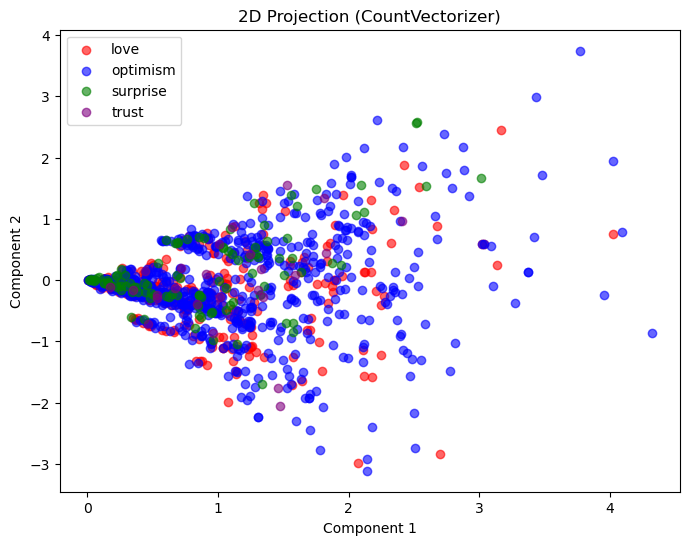

In [13]:
plot_2d(X_count_2d, y.values, "2D Projection (CountVectorizer)")

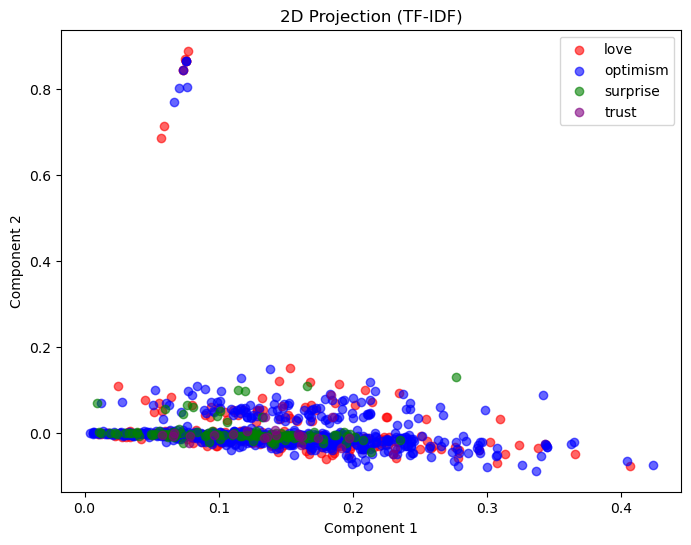

In [14]:
plot_2d(X_tfidf_2d, y.values, "2D Projection (TF-IDF)")

Which classes (if any) are visually separable (i.e., non-overlapping) for both plots? (0.5 point)
None of the four classes are visually separable in both CountVectorizer and TF-IDF plots.
They overlap significantly, so no class stands out as non-overlapping in the reduced 2D space.

Trying to plot with selecting mutiple true value varibales in a tweet.

In [ ]:
#classes = ['love', 'optimism', 'surprise', 'trust']
#df_selected = df[df[classes].any(axis=1)]
#X_text = df_selected['Tweet']
#df_melted = df_selected.melt(id_vars=['Tweet'], value_vars=classes, var_name='label', value_name='is_true')
#df_melted = df_melted[df_melted['is_true']]
#X_text = df_melted['Tweet']
#y = df_melted['label']

In [ ]:
#count_vec = CountVectorizer()
#X_count = count_vec.fit_transform(X_text)

#tfidf_vec = TfidfVectorizer()
#X_tfidf = tfidf_vec.fit_transform(X_text)

In [ ]:
#print("CountVectorizer shape:", X_count.shape)
#print("TfidfVectorizer shape:", X_tfidf.shape)

CountVectorizer shape: (1490, 4744)
TfidfVectorizer shape: (1490, 4744)


In [ ]:
#svd = TruncatedSVD(n_components=2, random_state=42)
#X_count_2d = svd.fit_transform(X_count)
#X_tfidf_2d = svd.fit_transform(X_tfidf)

In [ ]:
#def plot_2d(X, labels, title):
    plt.figure(figsize=(8,6))
    colors = {'love':'red', 'optimism':'blue', 'surprise':'green', 'trust':'purple'}
    for label, color in colors.items():
        idx = (labels == label)
        plt.scatter(X[idx,0], X[idx,1], c=color, label=label, alpha=0.6)
    plt.title(title)
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.legend()
    plt.show()


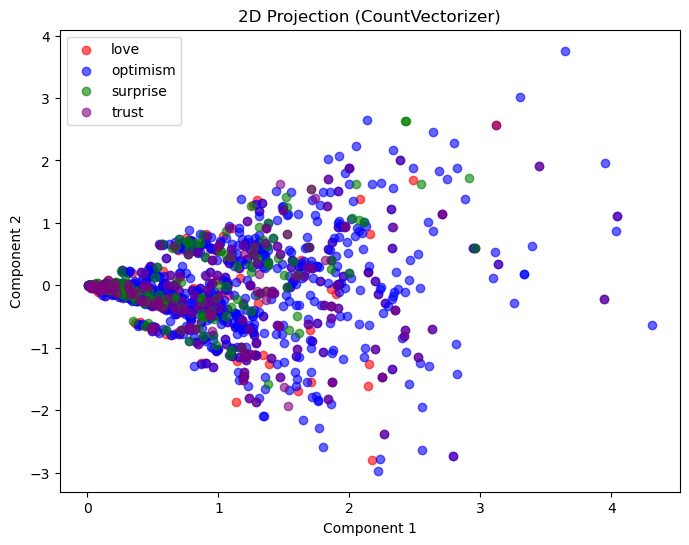

In [ ]:
#plot_2d(X_count_2d, y.values, "2D Projection (CountVectorizer)")


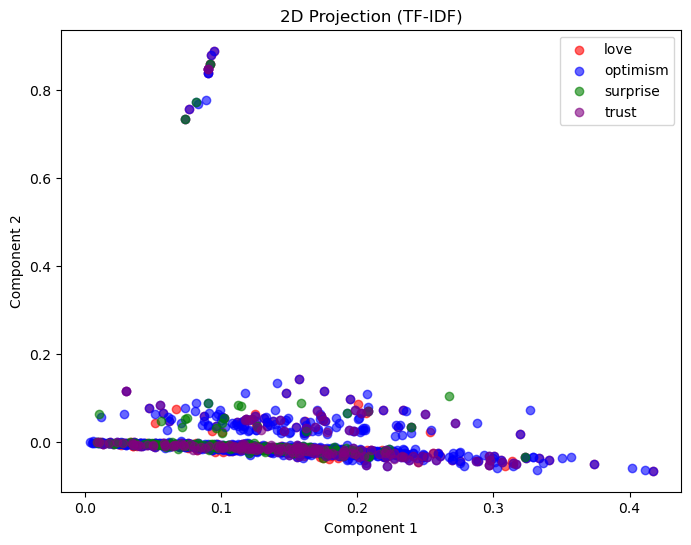

In [ ]:
#plot_2d(X_tfidf_2d, y.values, "2D Projection (TF-IDF)")